In [1]:
using Pkg
Pkg.activate("..")
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()
import HybridDynamics as HD
using LinearAlgebra
import Plots as plt


  Activating project at `c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl`
     Project No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Manifest.toml`
Precompiling packages...
   1878.8 ms  ✓ HybridDynamics
  1 dependency successfully precompiled in 3 seconds. 110 already precompiled.


In [2]:
fixed_solvers = Dict(
    "Forward Euler"          => HD.ForwardEuler(),
    "Backward Euler"         => HD.BackwardEuler(),
    "Modified Trapezoid"     => HD.ModifiedTrap(),
    "Modified Midpoint"      => HD.ModifiedMidpoint(),
    "Richardson Extrap."     => HD.RichardsonExtrapolation(),
    "RK4"                    => HD.RK4(),
    "Adams-Bashforth 2"      => HD.AdamsBashforth2(),
    "Adams-Bashforth 3"      => HD.AdamsBashforth3(),
    "BDF2"                   => HD.BDF2()
)

Dict{String, HybridDynamics.AbstractODESolver} with 9 entries:
  "Adams-Bashforth 3"  => AdamsBashforth3()
  "RK4"                => RK4()
  "Backward Euler"     => BackwardEuler()
  "BDF2"               => BDF2()
  "Modified Midpoint"  => ModifiedMidpoint()
  "Forward Euler"      => ForwardEuler()
  "Modified Trapezoid" => ModifiedTrap()
  "Richardson Extrap." => RichardsonExtrapolation()
  "Adams-Bashforth 2"  => AdamsBashforth2()

In [3]:
adaptive_solvers = Dict(
    "Adaptive ABM2" => HD.AdaptiveABM2(),
    "Adaptive ABM3" => HD.AdaptiveABM3(),
    "RK23"          => HD.RK23(),
    "RK45"          => HD.RK45()
)

Dict{String, HybridDynamics.AbstractODESolver} with 4 entries:
  "RK23"          => RK23()
  "RK45"          => RK45()
  "Adaptive ABM2" => AdaptiveABM2()
  "Adaptive ABM3" => AdaptiveABM3()

In [4]:
function f_test(x, t)
    return [-x[1]]
end
h_test(x) = x[1] + 100.0
Δ_test(x) = x
sys = HD.GeneralSystem(f_test,h_test,Δ_test)
prob = HD.prob(sys,[1.0],(0.0, 2.0))

HybridDynamics.prob{HybridDynamics.GeneralSystem, Vector{Float64}, Tuple{Float64, Float64}}(HybridDynamics.GeneralSystem(Main.f_test, Main.h_test, Main.Δ_test, 0), [1.0], (0.0, 2.0))

In [5]:
exact_solution(t) = [exp(-t)]

exact_solution (generic function with 1 method)

In [6]:
dts = 2.0 .^ (-(2:10));

In [7]:

function convergence_test(prob, solver, exact_solution; dts)
    errors = zeros(length(dts))
    tf = prob.tspan[end]
    for (i, dt) in enumerate(dts)
        sol = HD.solve(prob,solver;dt_initial = dt)
        errors[i] = norm(sol.x[end] - exact_solution(tf))
    end
    return errors
end


convergence_test (generic function with 1 method)

In [8]:

function estimate_order(dts, errors)
    logh = log10.(dts)
    loge = log10.(errors)
    A = hcat(logh, ones(length(logh)))
    p = A \ loge
    return p[1]
end


estimate_order (generic function with 1 method)

In [9]:

orders = Dict()
for (name, solver) in fixed_solvers
    errors = convergence_test(prob,solver,exact_solution;dts = dts)
    order = estimate_order(dts, errors)
    orders[name] = order
    println(rpad(name, 25), " → ", round(order, digits = 4))
end


Adams-Bashforth 3         → 2.9743
RK4                       → 4.033
Backward Euler            → 0.9939
BDF2                      → 1.9748
Modified Midpoint         → 2.0286
Forward Euler             → 1.0059
Modified Trapezoid        → 2.0286
Richardson Extrap.        → 3.0216
Adams-Bashforth 2         → 1.9799


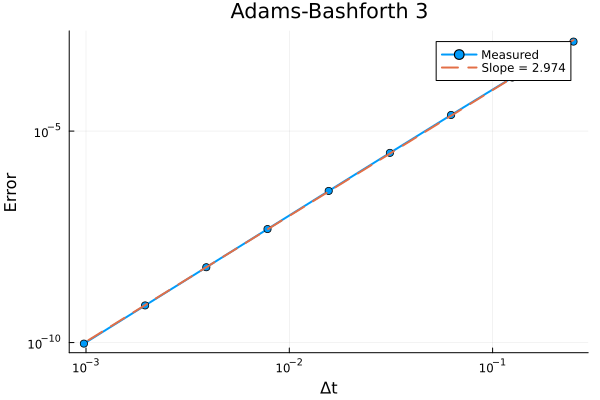

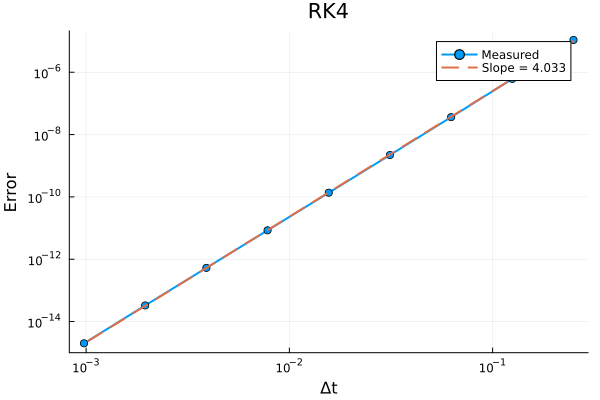

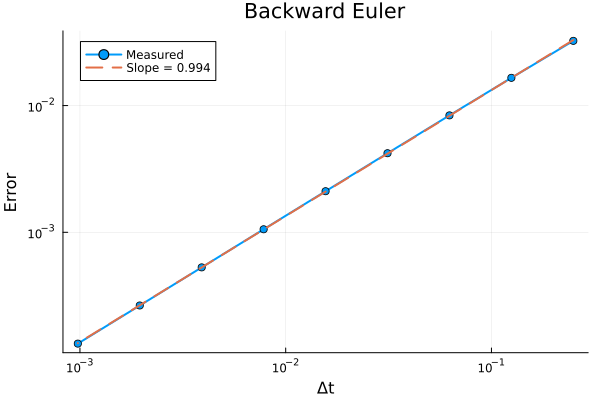

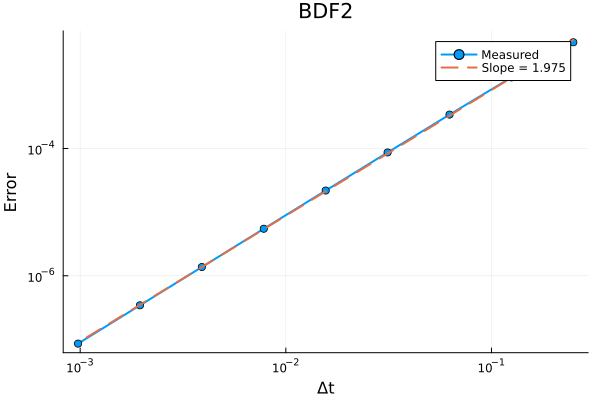

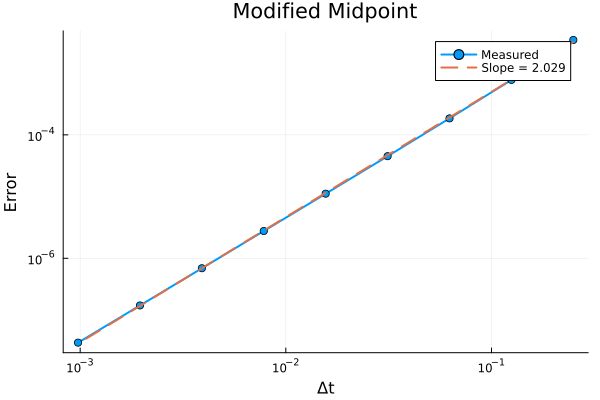

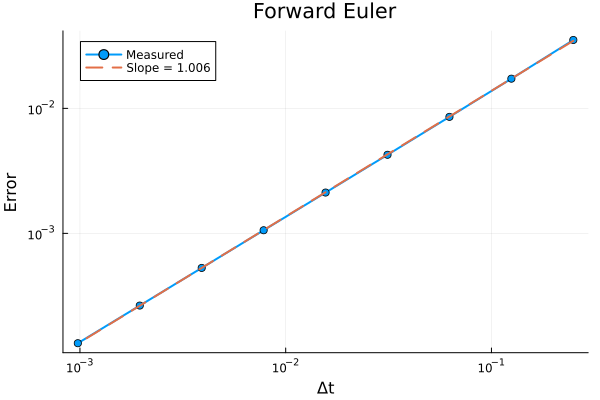

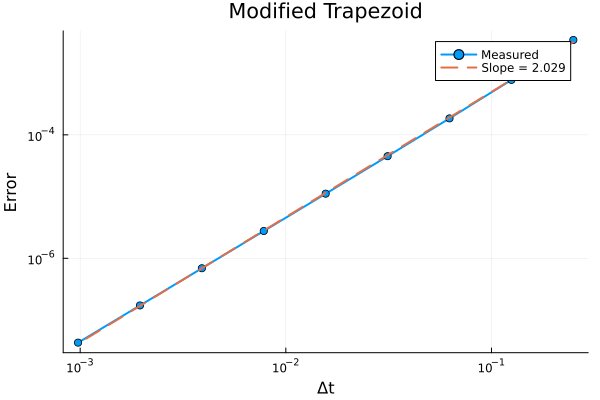

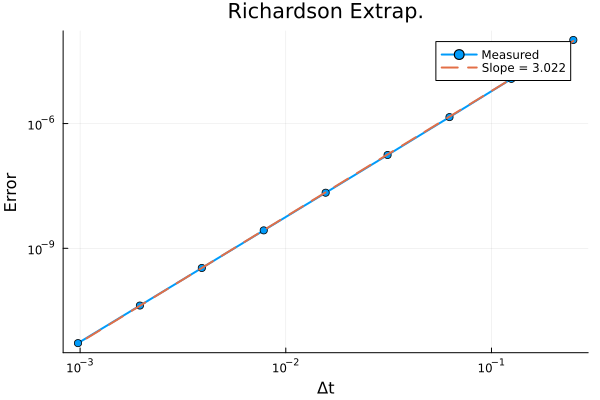

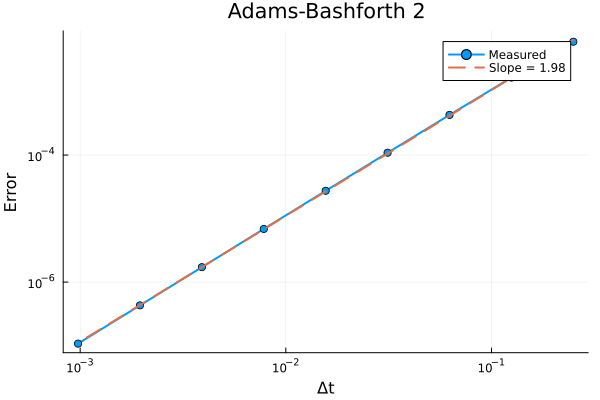

In [10]:
for (name, solver) in fixed_solvers
    errors = convergence_test(prob,solver,exact_solution;dts = dts)
    order = estimate_order(dts, errors)
    logh = log10.(dts)
    loge = log10.(errors)
    p = hcat(logh, ones(length(logh))) \ loge
    plt.plot(dts,errors; xscale = :log10,yscale = :log10,marker = :circle,lw = 2, xlabel = "Δt", ylabel = "Error", label = "Measured")
    plt.plot!(dts,10^(p[2]) .* dts .^ order;ls = :dash, lw = 2,label = "Slope = $(round(order, digits = 3))")
    plt.title!("$name")
    display(plt.current())
end

In [14]:
function test_convergence(sys_generator, x0, tspan, exact_solution; dts = 2.0 .^ (-(2:10)), solvers = fixed_solvers)
    orders = Dict{String, Float64}()
    
    println(rpad("Solver", 25), " | ", "Estimated Order")
    println("-"^45)
    
    for (name, solver) in solvers
        # Generate a fresh problem to avoid state leakage across runs
        prob = HD.prob(sys_generator(), x0, tspan)
        tf = tspan[end]
        
        errors = zeros(length(dts))
        for (i, dt) in enumerate(dts)
            sol = HD.solve(prob, solver; dt_initial = dt)
            # Compute error against exact analytical solution
            errors[i] = norm(sol.x[end] - exact_solution(tf))
        end
        
        # Estimate order via least squares
        logh = log10.(dts)
        loge = log10.(errors)
        A_lstsq = hcat(logh, ones(length(logh)))
        p = A_lstsq \ loge
        
        order = p[1]
        orders[name] = order
        println(rpad(name, 25), " → ", round(order, digits = 4))
    end
    
    return orders
end

test_convergence (generic function with 1 method)

In [32]:
F_fil(x) = [-x[1], -x[2]]
G_fil(x) = [0.0, 0.0]
H_fil(x) = x[1] + 100.0  # Guard placed safely out of bounds
N_fil(x) = [1.0, 0.0]

sys_gen_fil() = HD.FilippovSystem(F_fil, G_fil, H_fil, N_fil)

# Exact analytical solution: x(t) = exp(-t) * x0
exact_fil(t) = [exp(-t), exp(-t)]

fil_orders = test_convergence(sys_gen_fil, [1.0, 1.0], (0.0, 2.0), exact_fil);

Solver                    | Estimated Order
---------------------------------------------
Adams-Bashforth 3         → 2.9743
RK4                       → 4.033
Backward Euler            → 0.9939
BDF2                      → 1.9748
Modified Midpoint         → 2.0286
Forward Euler             → 1.0059
Modified Trapezoid        → 2.0286
Richardson Extrap.        → 3.0216
Adams-Bashforth 2         → 1.9799


In [33]:

M_mech(q) = [1.0 0.0; 0.0 1.0]
V_mech(q) = 0.5 * (q[1]^2 + q[2]^2)   # V(q) = 0.5 * qᵀ * q
h_mech(q) = q[1] + 100.0              # Guard safely out of bounds
∇h_mech(q) = [1.0, 0.0]

sys_gen_mech() = HD.MechanicalSystem(M_mech, V_mech; guard=h_mech, normal=∇h_mech, e=1.0)

# Initial conditions: q0 = [1.0, 0.0], v0 = [0.0, 1.0]
x0_mech = [1.0, 0.0, 0.0, 1.0]

# Exact solution
# q1(t) = cos(t),  q2(t) = sin(t)
# v1(t) = -sin(t), v2(t) = cos(t)
exact_mech(t) = [cos(t), sin(t), -sin(t), cos(t)]

mech_orders = test_convergence(sys_gen_mech, x0_mech, (0.0, 1.0), exact_mech);

Solver                    | Estimated Order
---------------------------------------------
Adams-Bashforth 3         → 2.8214
RK4                       → 4.0046
Backward Euler            → 0.9892
BDF2                      → 1.8701
Modified Midpoint         → 1.9999
Forward Euler             → 1.0069
Modified Trapezoid        → 1.9999
Richardson Extrap.        → 3.0001
Adams-Bashforth 2         → 1.9093


In [36]:
M_nh(q) = [1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 1.0] .* one(eltype(q))

V_nh(q) = 0.5 * (q[1]^2 + q[2]^2)

A_nh(q) = [-sin(q[3]) cos(q[3]) 0.0]

h_nh(q) = q[1] + 100.0  # Guard safely out of bounds
∇h_nh(q) = [1.0, 0.0, 0.0]

sys_gen_nh() = HD.NonholonomicSystem(M_nh, V_nh; A=A_nh, guard=h_nh, normal=∇h_nh, e=1.0)

x0_nh = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]

exact_nh(t) = [cos(t), 0.0, 0.0, -sin(t), 0.0, 0.0]

nh_orders = test_convergence(sys_gen_nh, x0_nh, (0.0, 1.0), exact_nh);

Solver                    | Estimated Order
---------------------------------------------
Adams-Bashforth 3         → 2.8214
RK4                       → 4.0046
Backward Euler            → 0.9892
BDF2                      → 1.8701
Modified Midpoint         → 1.9999
Forward Euler             → 1.0069
Modified Trapezoid        → 1.9999
Richardson Extrap.        → 3.0001
Adams-Bashforth 2         → 1.9093


In [34]:
A_lin = [-1.0 0.0; 0.0 -2.0]
λ_lin = [1.0, 0.0]
C_lin = [1.0 0.0; 0.0 1.0]

sys_gen_lin() = HD.LinearSystem(A_lin, λ_lin, C_lin)

# Exact solution: x_i(t) = exp(A_ii * t) * x_i(0)
exact_lin(t) = [exp(-t), exp(-2.0*t)]

# The guard is λx = 0 (which means x1 = 0). 
# We start at x1 = 1. It decays toward 0 but never crosses it in finite time.
lin_orders = test_convergence(sys_gen_lin, [1.0, 1.0], (0.0, 2.0), exact_lin);

Solver                    | Estimated Order
---------------------------------------------
Adams-Bashforth 3         → 3.038
RK4                       → 4.0595
Backward Euler            → 1.0002
BDF2                      → 1.995
Modified Midpoint         → 2.0516
Forward Euler             → 0.9986
Modified Trapezoid        → 2.0516
Richardson Extrap.        → 3.039
Adams-Bashforth 2         → 1.9921


In [35]:
A_aff = [-1.0 0.0; 0.0 -1.0]
b_aff = [2.0, 3.0]
λ_aff = [1.0, 0.0]
a_aff = 100.0  # Guard is λx + a = 0, which means x1 + 100 = 0 (out of bounds)
C_aff = [1.0 0.0; 0.0 1.0]
κ_aff = [0.0, 0.0]

sys_gen_aff() = HD.AffineSystem(A_aff, b_aff, λ_aff, a_aff, C_aff, κ_aff)

# Exact solution for dx/dt = -x + c is x(t) = c + (x(0) - c)*exp(-t)
exact_aff(t) = [2.0 - exp(-t), 3.0 - 2.0*exp(-t)]

aff_orders = test_convergence(sys_gen_aff, [1.0, 1.0], (0.0, 2.0), exact_aff);

Solver                    | Estimated Order
---------------------------------------------
Adams-Bashforth 3         → 2.9743
RK4                       → 3.9659
Backward Euler            → 0.9939
BDF2                      → 1.9748
Modified Midpoint         → 2.0286
Forward Euler             → 1.0059
Modified Trapezoid        → 2.0286
Richardson Extrap.        → 3.0216
Adams-Bashforth 2         → 1.9799


Solver                    → Order
-----------------------------------
RK23                      → 0.6513
RK45                      → 0.4941
Adaptive ABM2             → 0.9035


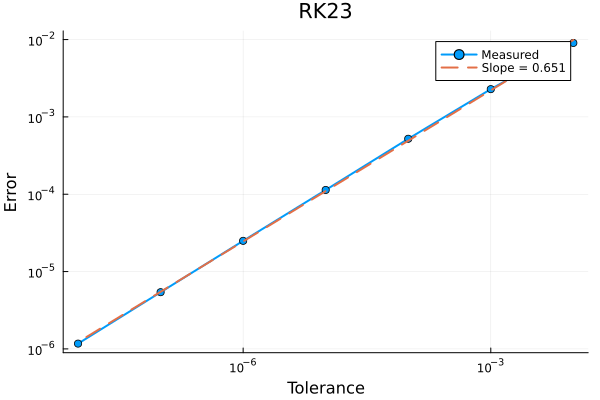

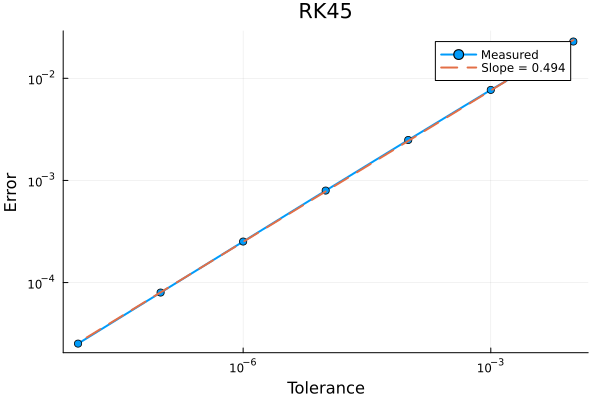

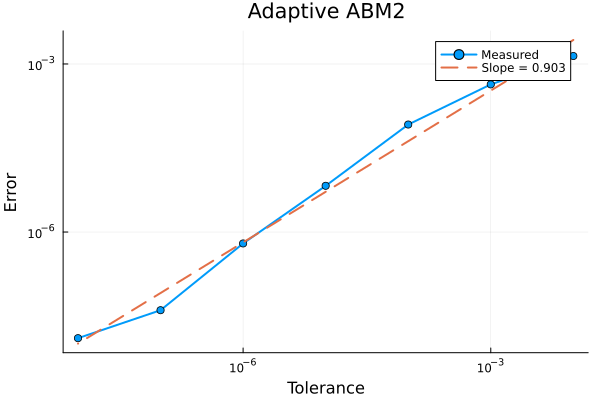

┌ Warning: LMM Step size has decreased below 1e-6
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\ODE_Solvers\Linear_Multistep_Methods\Adaptive_LMM_Steps.jl:106


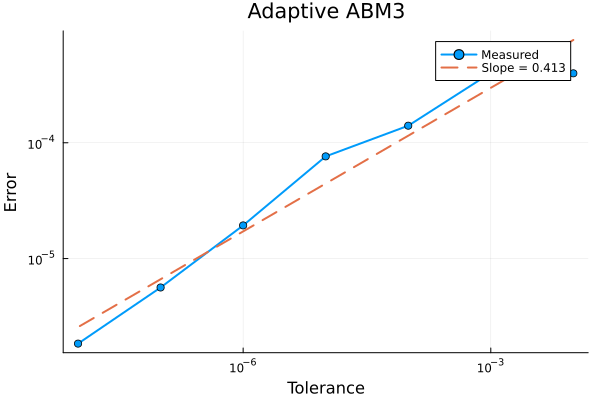

Adaptive ABM3             → 0.4133


┌ Warning: LMM Step size has decreased below 1e-6
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\ODE_Solvers\Linear_Multistep_Methods\Adaptive_LMM_Steps.jl:106
┌ Warning: LMM Step size has decreased below 1e-6
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\ODE_Solvers\Linear_Multistep_Methods\Adaptive_LMM_Steps.jl:106


In [37]:
# 1. Update the convergence test to iterate over tolerances instead of dt
function convergence_test_adaptive(prob, solver, exact_solution; tols)
    errors = zeros(length(tols))
    tf = prob.tspan[end]
    for (i, tol) in enumerate(tols)
        # Pass the tolerance to the solver
        sol = HD.solve(prob, solver; tol = tol, dt_initial = 0.1) 
        errors[i] = norm(sol.x[end] - exact_solution(tf))
    end
    return errors
end

# 2. Define a range of tolerances (typically 1e-2 down to 1e-8)
tols = 10.0 .^ (-(2:8))

# 3. Execution Loop
orders = Dict()
println(rpad("Solver", 25), " → ", "Order")
println("-"^35)

for (name, solver) in adaptive_solvers
    # Use tols instead of dts
    errors = convergence_test_adaptive(prob, solver, exact_solution; tols = tols)
    
    # Estimate order based on log10(tols) instead of log10(dts)
    order = estimate_order(tols, errors) 
    orders[name] = order
    println(rpad(name, 25), " → ", round(order, digits = 4))
    
    # Plotting: X-axis is now Tol
    logh = log10.(tols)
    loge = log10.(errors)
    p = hcat(logh, ones(length(logh))) \ loge
    
    plt.plot(tols, errors; xscale = :log10, yscale = :log10, marker = :circle, lw = 2, 
             xlabel = "Tolerance", ylabel = "Error", label = "Measured")
    plt.plot!(tols, 10^(p[2]) .* tols .^ order; ls = :dash, lw = 2, 
              label = "Slope = $(round(order, digits = 3))")
    plt.title!("$name")
    display(plt.current())
end